## Ejercicio de predicción de crecimiento de población de bacterias

In [2]:
from statistics import linear_regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# Construye un DF con las columnas:
temps = np.array([15,16,24,13,21,16,22,18,20,16,28,27,13,22,23])
humedades = np.array([70,65,71,64,84,86,72,84,71,75,84,79,80,76,88])
pob = np.array([156,157,177,145,197,184,172,187,157,169,200,193,167,170,192])

In [23]:
df = pd.DataFrame({
    'Temperatura': temps,
    'Humedad': humedades,
    'Pob': pob
})
df

,Temperatura,Humedad,Pob
0,15,70,156
1,16,65,157
2,24,71,177
3,13,64,145
4,21,84,197
5,16,86,184
6,22,72,172
7,18,84,187
8,20,71,157
9,16,75,169


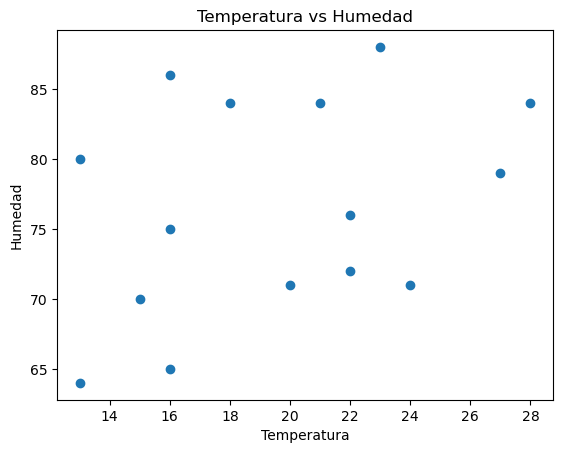

In [26]:
plt.scatter(df["Temperatura"], df["Humedad"])
plt.title("Temperatura vs Humedad")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.show()

In [28]:
cor_hum_temp = df[["Temperatura", "Humedad"]].corr()
cor_hum_temp

,Temperatura,Humedad
Temperatura,1.000000,0.355909
Humedad,0.355909,1.000000


In [29]:
lr = LinearRegression()
lr.fit(df[["Temperatura", "Humedad"]], df["Pob"])

LinearRegression()

In [36]:
R2 = lr.score(df[["Temperatura", "Humedad"]], df["Pob"])
R2

0.9139798458579923

In [37]:
a1 = lr.coef_[0]
a2 = lr.coef_[1]
a1, a2

(np.float64(1.5818179761771156), np.float64(1.5424478357820048))

In [38]:
a0 = lr.intercept_
a0

np.float64(25.71153011269365)

In [51]:
dic = {"Temperatura": [19], "Humedad": [81]}
df_nuevo = pd.DataFrame(dic)
df_nuevo

,Temperatura,Humedad
0,19,81


In [52]:
pob_pred = lr.predict(df_nuevo)
pob_pred

array([180.70434636])

In [53]:
df_nuevo["Pob"] = pob_pred
df_nuevo

,Temperatura,Humedad,Pob
0,19,81,180.704346


#### Si quisieramos solamente una regresión de una variable.

In [54]:
lr1 = LinearRegression()
lr1.fit(df[["Temperatura"]], df["Pob"])

LinearRegression()

In [43]:
m = lr1.coef_[0]
b = lr1.intercept_
print("Coeficiente = ", m, "Intersección = ", b)

Coeficiente =  2.4630788485607007 Intersección =  126.59032123487694


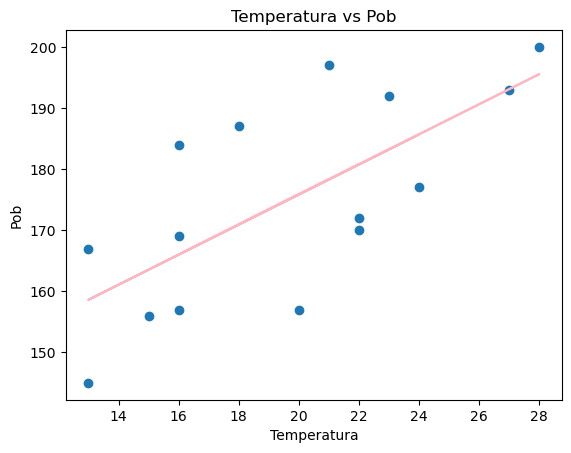

In [44]:
recta = m*df["Temperatura"] + b

plt.scatter(df["Temperatura"], df["Pob"])
plt.plot(df["Temperatura"], recta, color = "lightpink")
plt.title("Temperatura vs Pob")
plt.xlabel("Temperatura")
plt.ylabel("Pob")
plt.show()

#### Y de humedad y población

In [62]:
R2_rec1 = lr1.score(df[["Temperatura"]], df["Pob"])
R2_rec1

0.48549452548667504

In [55]:
lr2 = LinearRegression()
lr2.fit(df[["Humedad"]], df["Pob"])

LinearRegression()

In [56]:
m1 = lr2.coef_[0]
b1 = lr2.intercept_
print("Coeficiente = ", m1, "Intersección = ", b1)

Coeficiente =  1.8931520155415253 Intersección =  29.851222276185837


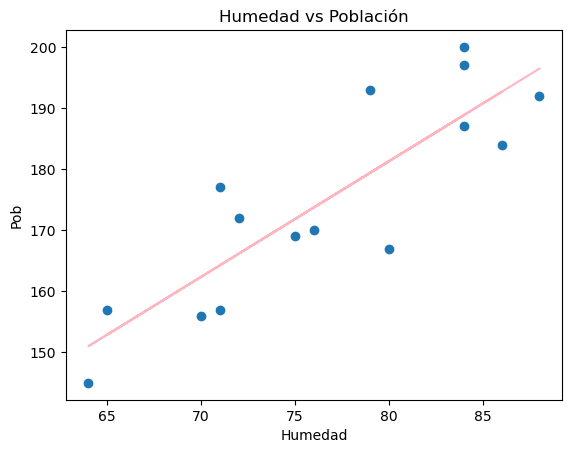

In [58]:
recta1 = m1*df["Humedad"] + b1

plt.scatter(df["Humedad"], df["Pob"])
plt.plot(df["Humedad"], recta1, color = "lightpink")
plt.title("Humedad vs Población")
plt.xlabel("Humedad")
plt.ylabel("Pob")
plt.show()

In [61]:
R2_rec2 = lr2.score(df[["Humedad"]], df["Pob"])
R2_rec2

0.7391085924529294